In [2]:
import numpy as np
#if this fails, you need to put the case_studies.py file in the same folder
from case_studies import *

In [4]:
from scipy.optimize import minimize

#These are the example optimizers you should evaluate this week.
#These are optimizers implemented in scipy.
#they take as first 2 or 3 arguments the function f, its gradient df and sometimes its hessian Hf.
#the next parameters are all the same: x0 is the starting point, max_iterations the stopping criterion for iterations
#and epsilon the precision tolerance to be reached. 
#Note: epsilon is interpreted slightly differently across algorithms, and some algorithms might not reach the tolerance
#and stop early.
def scipy_bfgs(f,df,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="BFGS", jac=df, tol=epsilon,options={'maxiter':max_iterations, 'gtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_newton(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="Newton-CG", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations,'xtol':epsilon})
    return np.array(xs), np.array(grad_norms)

def scipy_trust_region(f,df,Hf,x0,max_iterations,epsilon):
    xs=[]
    grad_norms=[]
    def logging_f(x):
        xs.append(x)
        grad_norms.append(np.maximum(np.linalg.norm(df(x)),10**(-5)*epsilon))
        return f(x)
    minimize(logging_f, x0, method="trust-exact", jac=df, hess=Hf, tol=epsilon,options={'maxiter':max_iterations})
    return np.array(xs), np.array(grad_norms)

In [4]:
#example usage of the algorithms
#the output is a list of points evaluated on the function as well as the gradient norms at that point
#this algorithms has the first three arguments functions for function value, gradient and Hessian.
#For the 5 functions, those are named f1-f5 etc and cna be found in the case_studies.py file
x0=np.ones(2)
xs,grad_norms = scipy_trust_region(f4,df4,Hf4,x0, 1000, 1.e-10)

#the optimal point for a given function and dimensionality is stored in the package as well for at least 15 decimals precision
optimal = x_opt("f4", 2)
print("final solution point:", xs[-1])
print("distance of x from optimum", np.linalg.norm(xs[-1]-optimal))
print("number of function evaluations:", len(grad_norms))
print("final function value:", f4(xs[-1]))
print("final gradient norm:", grad_norms[-1])



final solution point: [0.00190933 0.00190933]
distance of x from optimum 1.1857524696459338e-11
number of function evaluations: 9
final function value: 1.2203194789920598e-05
final gradient norm: 9.977761920841575e-11


In [5]:
import numpy as np
import matplotlib.pyplot as plt

F1 = np.array(["f1", f1, df1, Hf1])
F2 = np.array(["f2", f2, df2, Hf2])
F3 = np.array(["f3", f3, df3, Hf3])
F4 = np.array(["f4", f4, df4, Hf4])
F5 = np.array(["f5", f5, df5, Hf5])
F = np.array([F1, F2, F3, F4, F5])

O1 = np.array(["scipy_bfgs", scipy_bfgs, 'blue'])
O2 = np.array(["scipy_newton", scipy_newton, 'orange'])
O3 = np.array(["scipy_trust_region", scipy_trust_region, 'green'])
O = np.array([O1, O2, O3])

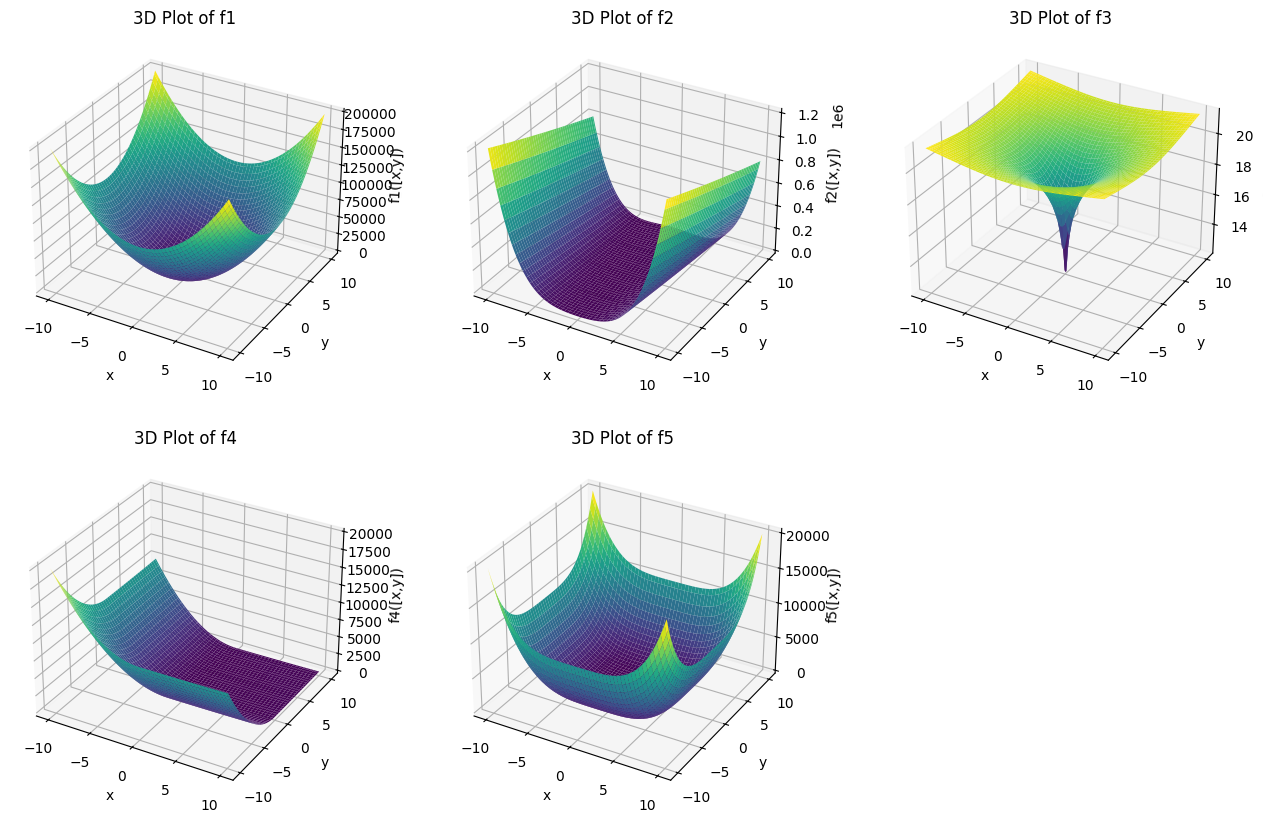

In [6]:
def plot_functions(F_list):
    # Generate grid for x and y
    limit = 10
    x_vals = np.linspace(-limit, limit, 100)
    y_vals = np.linspace(-limit, limit, 100)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # Determine the layout of subplots
    num_plots = len(F_list)
    cols = 3  # Number of columns in the subplot grid
    rows = (num_plots + cols - 1) // cols  # Number of rows needed

    fig = plt.figure(figsize=(16, 5*rows))  # Adjust figure size to fit all subplots

    for i, f in enumerate(F_list):
        # Compute Z values for the grid
        Z = np.array([f[1](np.array([[x], [y]])) for x, y in zip(np.ravel(X), np.ravel(Y))])
        Z = Z.reshape(X.shape)
        # Create subplot
        ax = fig.add_subplot(rows, cols, i + 1, projection='3d')
        # Plot the surface
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
        # Add title and labels
        ax.set_title(f"3D Plot of {f[0]}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel(f"{f[0]}([x,y])")

    # Adjust layout for better appearance
    # plt.tight_layout()
    plt.show()

plot_functions(F)

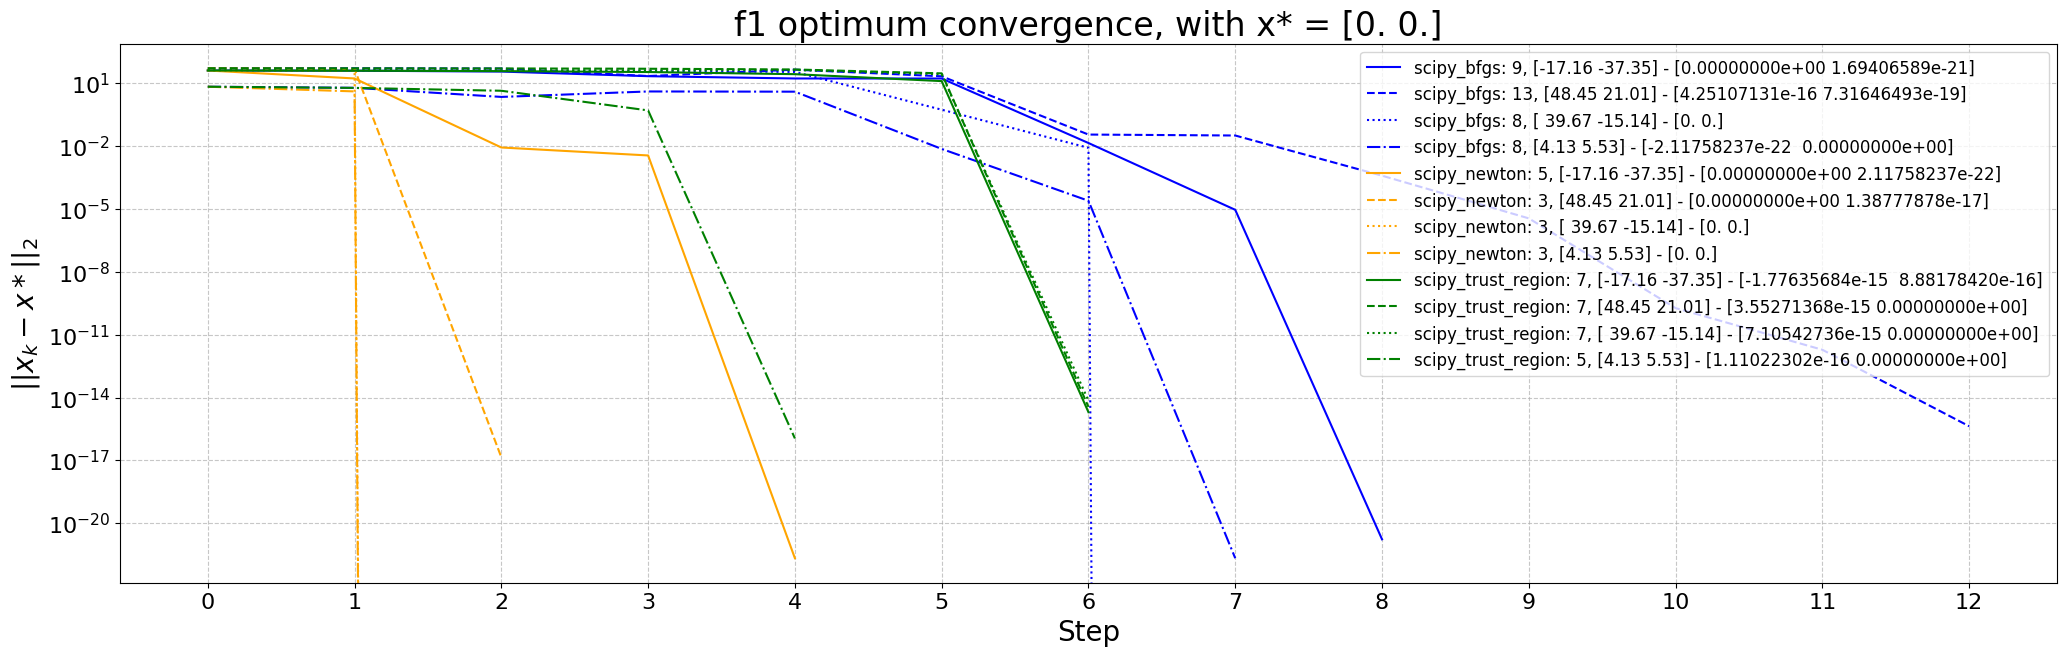

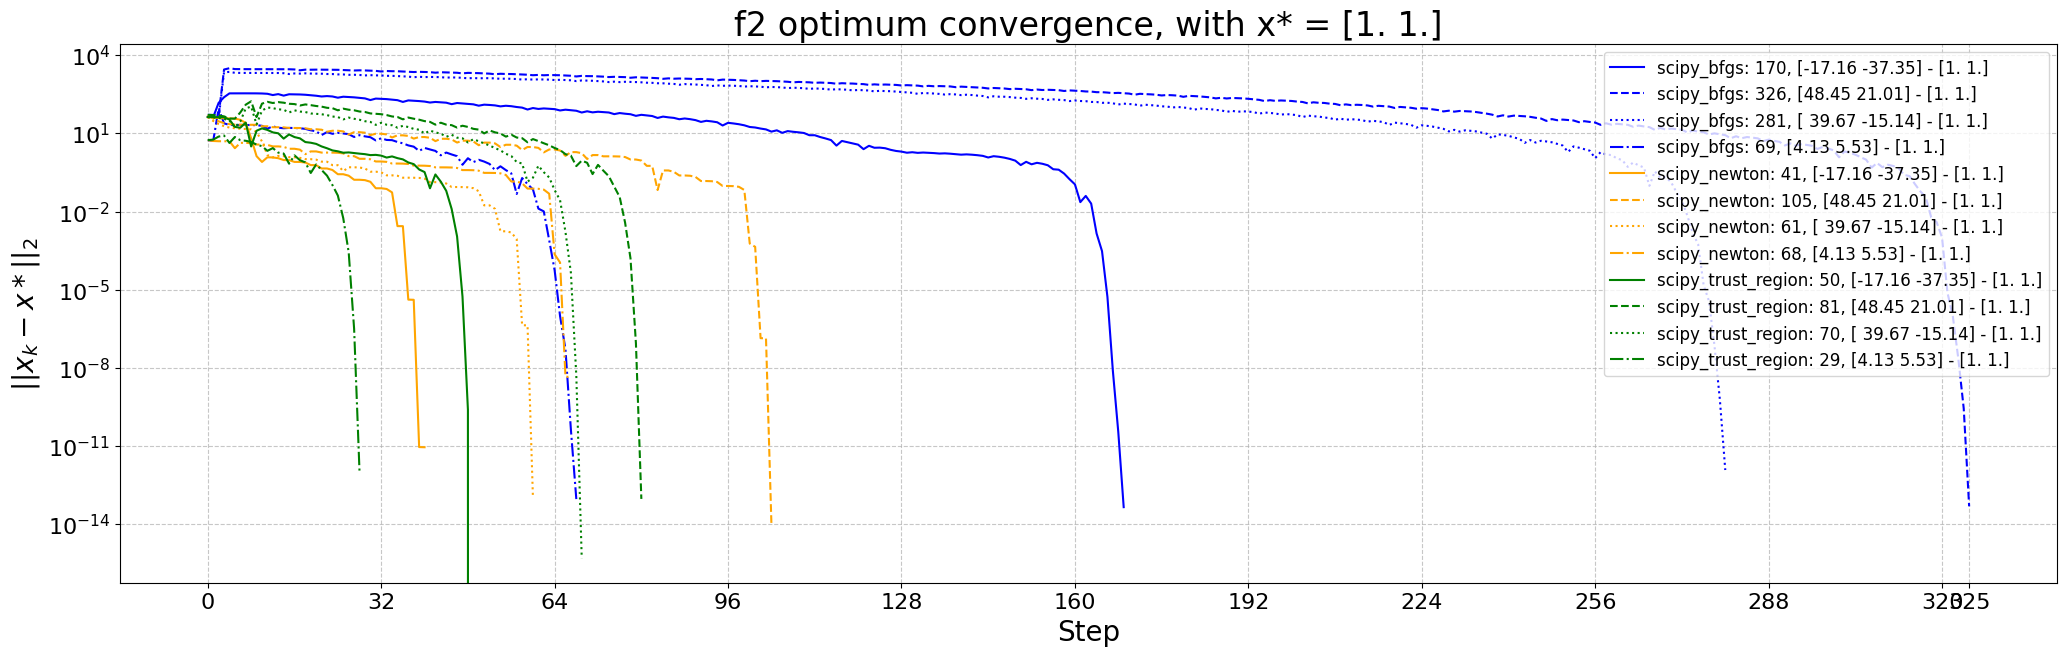

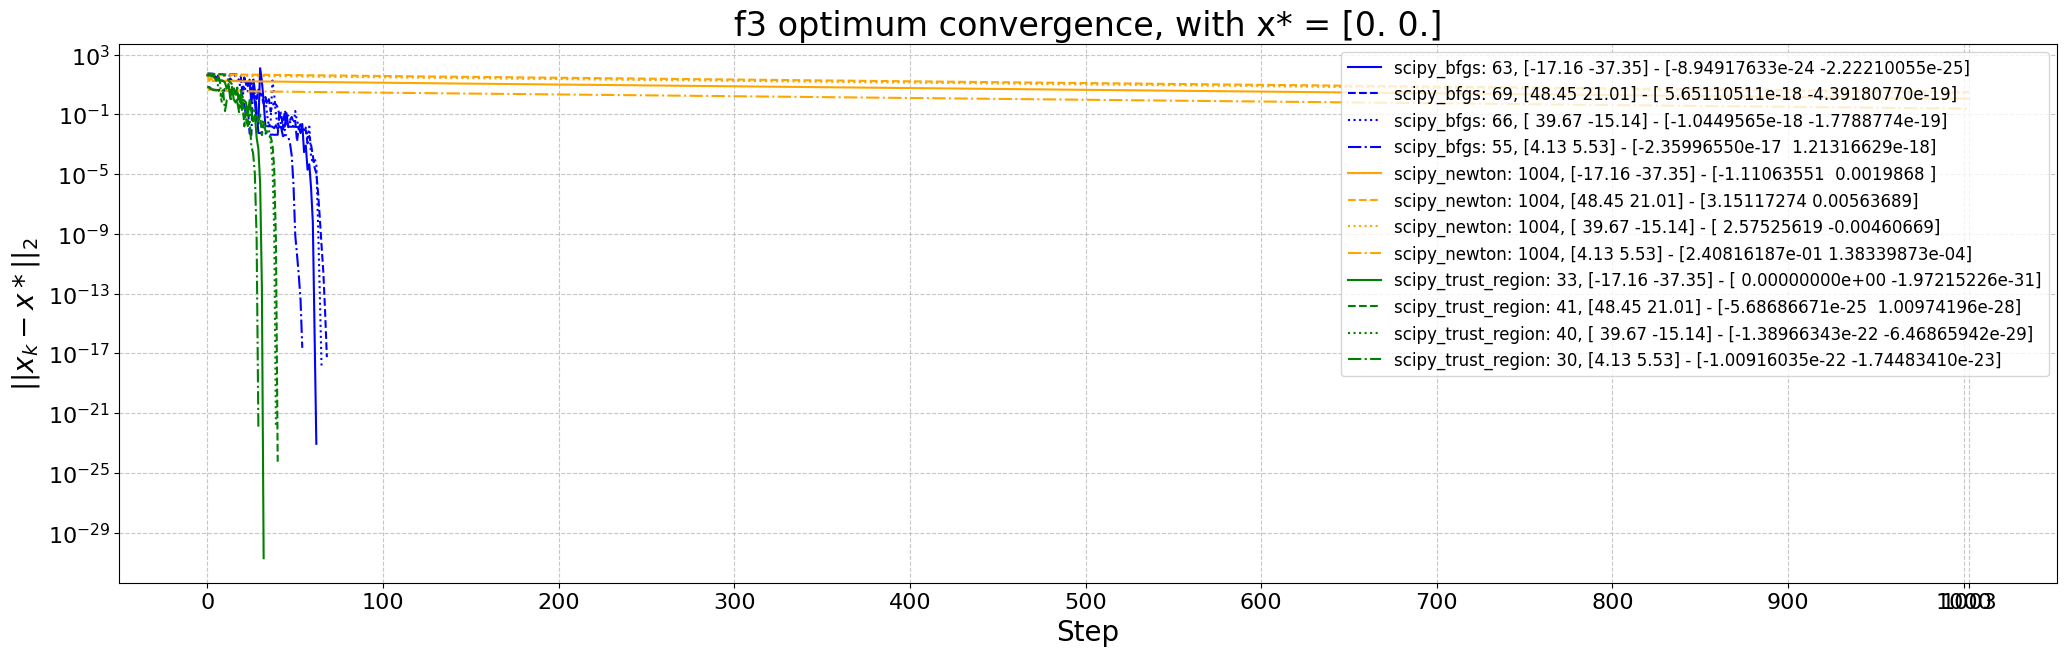

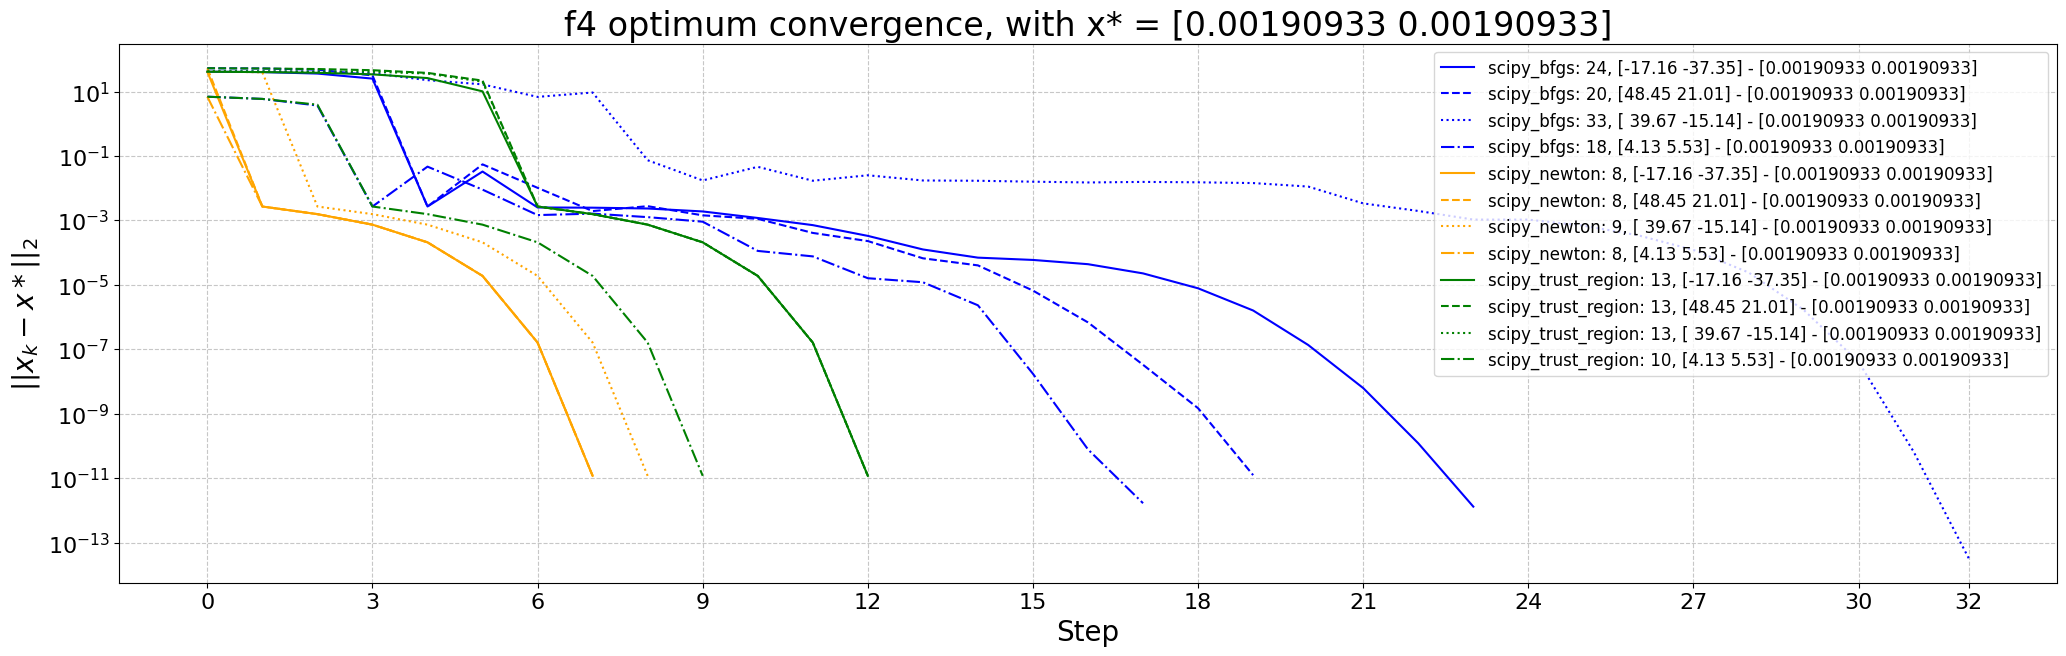

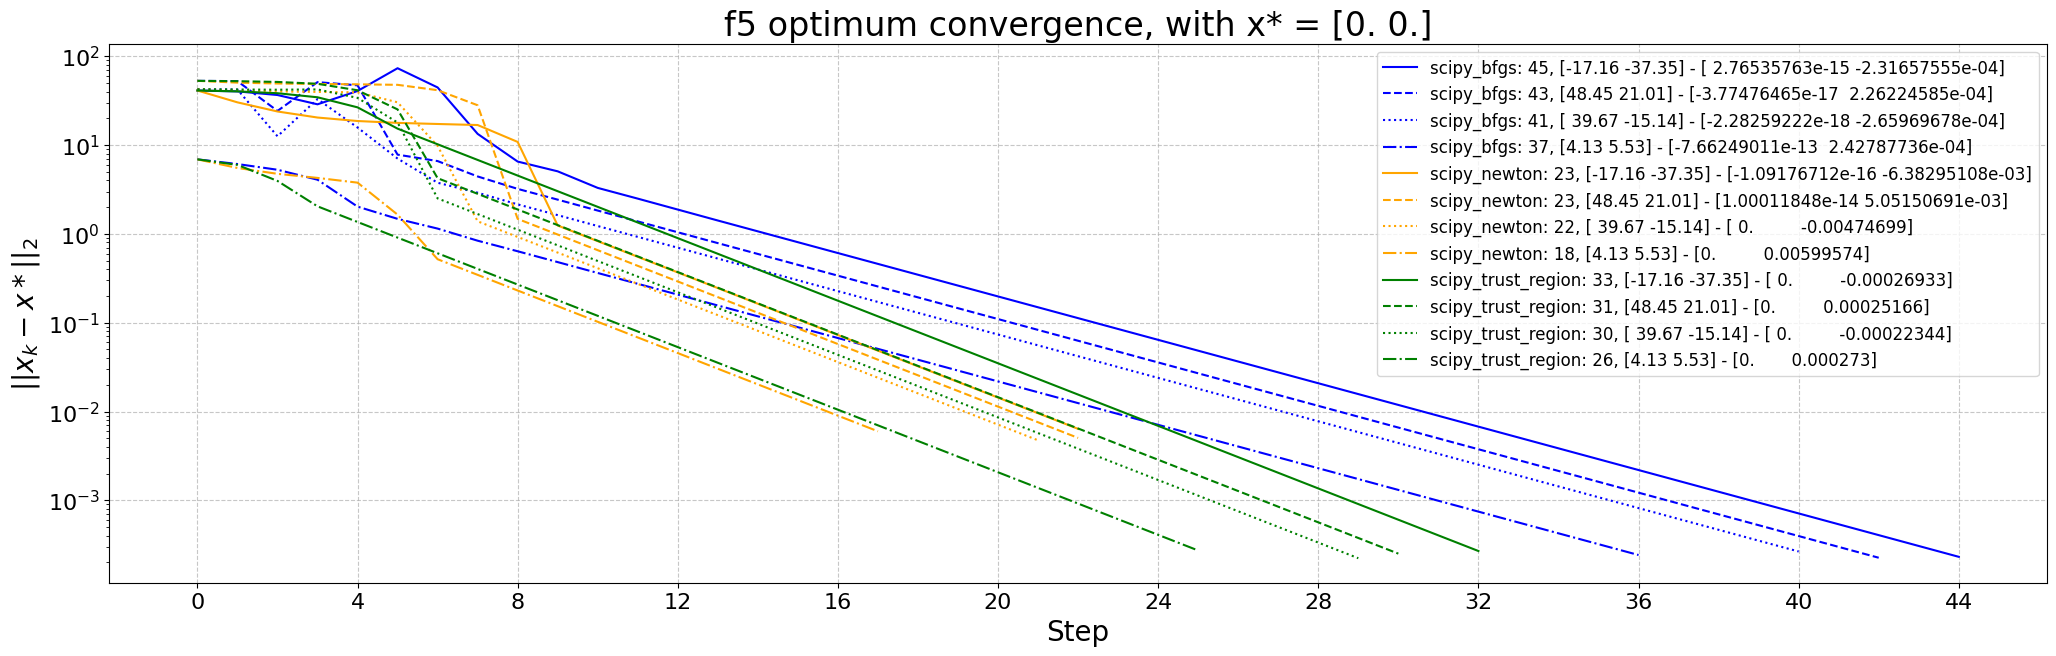

In [ ]:
def plot_optimizers(F, O, xs):
    line_styles = ['-', '--', ':', '-.']
    
    for idx, f in enumerate(F, 1):
        plt.figure(figsize=(25, 7))
        plt.yscale("log")
        optimal = x_opt(f[0], 2)
        t = 0
        for o in O:
            for i, x0 in enumerate(xs):
                max_iterations, epsilon = 1000, 1.e-10
                if (o[1] == scipy_bfgs):
                    xk,grad_norms = o[1](f[1],f[2],x0,max_iterations,epsilon)
                else:
                    xk,grad_norms = o[1](f[1],f[2],f[3],x0,max_iterations,epsilon)
                t = (len(xk) if t < len(xk) else t)
                N = [np.linalg.norm(v, ord=2) for v in xk-np.full_like(xk, optimal)]
                label = f"{o[0]}: {len(xk)}, {np.array2string(x0, precision=2)} - {xk[-1]}"
                plt.plot(range(0,len(xk)), N, 
                        label=label, 
                        color=o[2], 
                        linestyle=line_styles[i % len(line_styles)])
        
        plt.legend(loc='upper right', fontsize=12)    
        plt.title(f"{f[0]} optimum convergence, with x* = {optimal}", fontsize=24)
        plt.xlabel("Step", fontsize=20)
        plt.ylabel("$||x_k - x*||_2$", fontsize=20)
        
        # Show only 10 ticks on x-axis
        num_ticks = 10
        step = max(t // num_ticks, 1)
        xticks_positions = list(range(0, t, step))
        if t-1 not in xticks_positions:
            xticks_positions.append(t-1)
        plt.xticks(xticks_positions, xticks_positions, fontsize=16)
        
        # Reduce y-axis grid lines
        plt.gca().yaxis.set_major_locator(plt.LogLocator(numticks=10))
        plt.yticks(fontsize=16)
        
        # Only show major grid lines
        plt.grid(True, which='major', linestyle='--', alpha=0.7)
        plt.grid(False, which='minor')
        plt.show()
        # plt.savefig(f'{idx}.png', bbox_inches='tight', dpi=300)
        # plt.close()

xs = []
for _ in range(4):
    # xs.append(np.random.normal(0, 10, size=2))
    xs.append(np.random.uniform(-50, 50+1, size=2))  
    # xs.append(np.random.randint(-10, 10+1, size=2))  
    np.ones(2)  

plot_optimizers(F, O, xs)

/var/folders/xv/yzvxcq3s2ql6nk47wg_l5xrr0000gn/T/ipykernel_50686/3803217917.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=runtime_df, x='Function', y='Runtime (s)',



Average Runtime Results (seconds):
                               mean     std
Function Optimizer                         
f1       scipy_bfgs          0.0046  0.0090
         scipy_newton        0.0005  0.0007
         scipy_trust_region  0.0025  0.0049
f2       scipy_bfgs          0.0001  0.0001
         scipy_newton        0.0001  0.0000
         scipy_trust_region  0.0001  0.0001
f3       scipy_bfgs          0.0028  0.0003
         scipy_newton        0.1132  0.0094
         scipy_trust_region  0.0028  0.0001
f4       scipy_bfgs          0.0013  0.0002
         scipy_newton        0.0012  0.0001
         scipy_trust_region  0.0015  0.0002
f5       scipy_bfgs          0.0017  0.0001
         scipy_newton        0.0009  0.0000
         scipy_trust_region  0.0018  0.0000


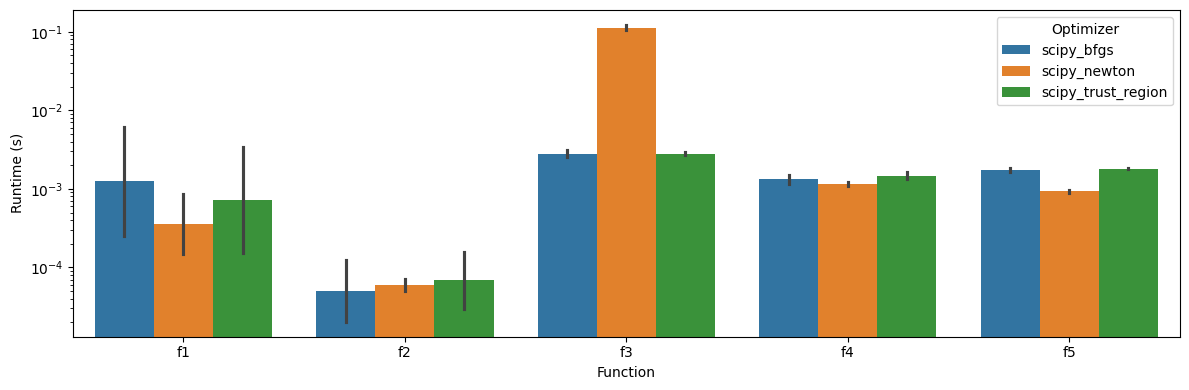

In [19]:
import time
import seaborn as sns
import pandas as pd

def measure_runtime_with_trials(F, O, x0, n_trials=5, max_iterations=1000, epsilon=1.e-10):
    results = {
        'Function': [],
        'Optimizer': [],
        'Runtime (s)': [],
        'Trial': []
    }
    
    for f in F:
        for o in O:
            for trial in range(n_trials):
                start_time = time.time()
                
                if o[0] == 'scipy_bfgs':
                    o[1](f[1], f[2], x0, max_iterations, epsilon)
                else:
                    o[1](f[1], f[2], f[3], x0, max_iterations, epsilon)
                
                runtime = time.time() - start_time
                
                results['Function'].append(f[0])
                results['Optimizer'].append(o[0])
                results['Runtime (s)'].append(runtime)
                results['Trial'].append(trial)
    
    return pd.DataFrame(results)

# Measure runtime with multiple trials
runtime_df = measure_runtime_with_trials(F, O, x0, n_trials=5)

# Create bar plot with error bars
plt.figure(figsize=(12, 4))
plt.yscale("log")
sns.barplot(data=runtime_df, x='Function', y='Runtime (s)', 
            hue='Optimizer', ci='sd')
plt.tight_layout()
plt.savefig("k.png")

# Display average runtimes
print("\nAverage Runtime Results (seconds):")
pivot_table = runtime_df.groupby(['Function', 'Optimizer'])['Runtime (s)'].agg(['mean', 'std']).round(4)
print(pivot_table)